# Indicadores SNIS

#### Este código vai extrair os indicadores e gerar gráfico de perdas. Não mexa nos nomes nem nas pastas dentro do zip, apenas extraia-os na pasta desejada.

##### Altere o município e o caminho abaixo conforme desejado:

In [11]:
MUNICIPIO_SELECIONADO = "Concórdia" # <- Altere para o município desejado
DIRETORIO = r"C:\Users\gabriel.coimbra\Desktop\Concórdia\_SNIS\Antigo" # 🔹 Diretório onde estão os arquivos Excel

### ÁGUA
#### Tabela com indicadores  "ge12a", "ag001", "ag021", "ag003", "ag005", "in009", "in022", "in049".

In [13]:
import pandas as pd
import os
import re

# 🔹 Definir o município e os indicadores desejados

INDICADORES_SELECIONADOS = [
    "município", "ge12a","ag001","ag021","ag003","ag005","in009","in022","in049"
]  # <- Altere os indicadores conforme necessário

# Função para processar os arquivos conforme as regras definidas
def process_excel(file_path, municipio, indicadores):
    xls = pd.ExcelFile(file_path)
    all_sheets = {}

    is_info = "Info" in os.path.basename(file_path)

    for sheet_name in xls.sheet_names:
        df = pd.read_excel(xls, sheet_name=sheet_name, header=None)

        # Certifica que há linhas suficientes antes de definir os cabeçalhos
        if len(df) < 12:
            continue

        # Definir os cabeçalhos conforme o tipo do arquivo
        if is_info:
            header_row_1 = df.iloc[7]  
            header_row_2 = df.iloc[11]  
            start_row = 12  
        else:
            header_row_1 = df.iloc[7]  
            header_row_2 = df.iloc[9]  
            start_row = 10  

        # Criar novo cabeçalho
        new_headers = list(header_row_1[:10]) + list(header_row_2[10:])
        df.columns = [str(h).strip().lower() for h in new_headers]  

        # Remover as linhas de cabeçalho originais
        df = df.iloc[start_row:].reset_index(drop=True)

        # Verificar se há a coluna 'município'
        if df.empty or "município" not in df.columns:
            continue  

        # Filtrar pelo município selecionado
        df["município"] = df["município"].astype(str).str.strip().str.lower()
        df = df[df["município"] == municipio.lower()]

        # Manter apenas os indicadores desejados
        available_columns = [col for col in indicadores if col in df.columns]
        df = df[available_columns]

        # Extrair o ano do nome do arquivo
        match = re.search(r'\b(20\d{2})\b', os.path.basename(file_path))
        df["ano"] = match.group(1) if match else "Desconhecido"
        
        if not df.empty:
            all_sheets[sheet_name] = df

    return all_sheets

# 🔹 Processar os arquivos
arquivos_excel = [os.path.join(DIRETORIO, f) for f in os.listdir(DIRETORIO) if f.endswith(".xlsx")]

data_info = {}
data_ano = {}

for file in arquivos_excel:
    sheets = process_excel(file, MUNICIPIO_SELECIONADO, INDICADORES_SELECIONADOS)
    target_dict = data_info if "Info" in file else data_ano

    for sheet_name, df in sheets.items():
        if sheet_name not in target_dict:
            target_dict[sheet_name] = df  
        else:
            common_cols = target_dict[sheet_name].columns.intersection(df.columns)
            df = df[common_cols]  
            target_dict[sheet_name] = pd.concat([target_dict[sheet_name][common_cols], df], ignore_index=True)

# 🔹 Concatenar os dados separadamente
df_info_concat = pd.concat(data_info.values(), ignore_index=True) if data_info else pd.DataFrame()
df_ano_concat = pd.concat(data_ano.values(), ignore_index=True) if data_ano else pd.DataFrame()

# 🔹 Padronizar colunas antes do merge
for df in [df_info_concat, df_ano_concat]:
    if not df.empty:
        df["ano"] = df["ano"].astype(str).str.strip()
        df["município"] = df["município"].astype(str).str.strip().str.lower()

# 🔹 Realizar o merge
df_final = pd.merge(df_info_concat, df_ano_concat, on=["município", "ano"], how="outer")

# 🔹 Remover linhas vazias
df_final = df_final.dropna(how="all", subset=INDICADORES_SELECIONADOS)

# 🔹 Exportar os dados para Excel
if not df_final.empty:
    output_path = os.path.join(DIRETORIO, "Resultado", f"{MUNICIPIO_SELECIONADO}_Dados-Agua-Tabela.xlsx")
    df_final.to_excel(output_path, index=False)
    display(df_final)
    print(f"📂 Arquivo exportado para: {output_path}")
else:
    print(f"⚠ Nenhum dado encontrado para {MUNICIPIO_SELECIONADO}.")

,município,ge12a,ag001,ag021,ag003,ag005,ano,in009,in022,in049
0,concórdia,74106,67531,20471,25661,297.57,2018,99.73,121.2,53.08
1,concórdia,74641,68807,20814,26150,309.37,2019,99.73,122.36,53.07
2,concórdia,75167,71277,19711,27120,312.04,2020,99.99,125.08,58.05
3,concórdia,75683,73073,20209,27764,339.85,2021,99.8,122.34,52.82
4,concórdia,81646,74796,20494,28412,343.01,2022,99.67,118.65,51.83


📂 Arquivo exportado para: C:\Users\gabriel.coimbra\Desktop\Concórdia\_SNIS\Antigo\Resultado\Concórdia_Dados-Agua-Tabela.xlsx


### ÁGUA
#### Tabela com indicadores  "ag006", "ag010", "ag011", "ag024", "in049", "in013" + Gráfico de perdas

📂 Arquivo exportado para: C:\Users\gabriel.coimbra\Desktop\Concórdia\_SNIS\Antigo\Resultado\Concórdia_Dados-Agua-Grafico.xlsx


,município,ag006,ag010,ag011,ag024,ano,in049,in013
0,concórdia,6317.42,2961.35,3730.6,5.63,2018,53.08,40.89
1,concórdia,6490.71,3044.48,3842.77,3.36,2019,53.07,40.77
2,concórdia,7623.75,3197.82,3381.44,1.39,2020,58.05,55.64
3,concórdia,6945.31,3222.94,3267.33,114,2021,52.82,52.17
4,concórdia,6817.52,3201.91,3214.89,169.98,2022,51.83,51.64


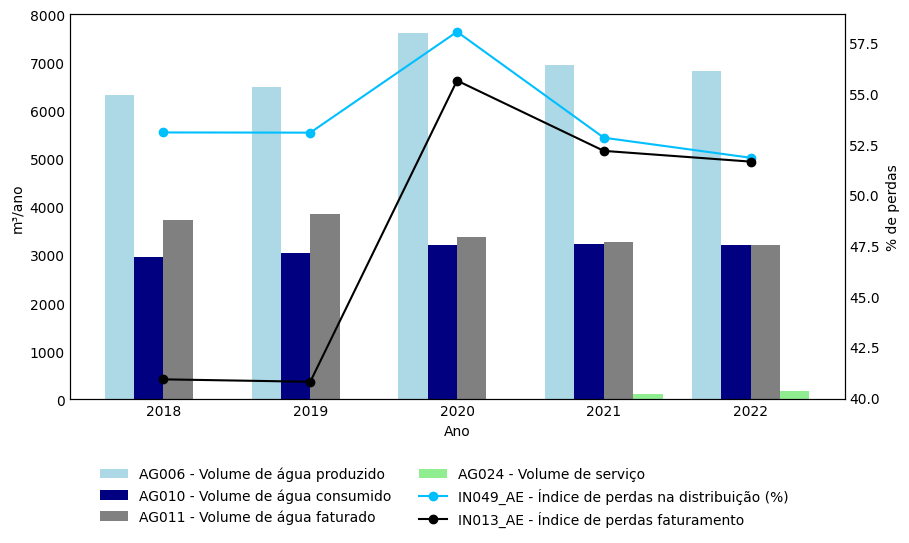

In [14]:
import pandas as pd
import os
import re

# 🔹 Definir o município e os indicadores desejados
INDICADORES_SELECIONADOS = [
    "município", "ag006", "ag010", "ag011", "ag024", "in049", "in013"
]  # <- Altere os indicadores conforme necessário

# Função para processar os arquivos conforme as regras definidas
def process_excel(file_path, municipio, indicadores):
    xls = pd.ExcelFile(file_path)
    all_sheets = {}

    is_info = "Info" in os.path.basename(file_path)

    for sheet_name in xls.sheet_names:
        df = pd.read_excel(xls, sheet_name=sheet_name, header=None)

        # Certifica que há linhas suficientes antes de definir os cabeçalhos
        if len(df) < 12:
            continue

        # Definir os cabeçalhos conforme o tipo do arquivo
        if is_info:
            header_row_1 = df.iloc[7]  
            header_row_2 = df.iloc[11]  
            start_row = 12  
        else:
            header_row_1 = df.iloc[7]  
            header_row_2 = df.iloc[9]  
            start_row = 10  

        # Criar novo cabeçalho
        new_headers = list(header_row_1[:10]) + list(header_row_2[10:])
        df.columns = [str(h).strip().lower() for h in new_headers]  

        # Remover as linhas de cabeçalho originais
        df = df.iloc[start_row:].reset_index(drop=True)

        # Verificar se há a coluna 'município'
        if df.empty or "município" not in df.columns:
            continue  

        # Filtrar pelo município selecionado
        df["município"] = df["município"].astype(str).str.strip().str.lower()
        df = df[df["município"] == municipio.lower()]

        # Manter apenas os indicadores desejados
        available_columns = [col for col in indicadores if col in df.columns]
        df = df[available_columns]

        # Extrair o ano do nome do arquivo
        match = re.search(r'\b(20\d{2})\b', os.path.basename(file_path))
        df["ano"] = match.group(1) if match else "Desconhecido"
        
        if not df.empty:
            all_sheets[sheet_name] = df

    return all_sheets

# 🔹 Processar os arquivos
arquivos_excel = [os.path.join(DIRETORIO, f) for f in os.listdir(DIRETORIO) if f.endswith(".xlsx")]

data_info = {}
data_ano = {}

for file in arquivos_excel:
    sheets = process_excel(file, MUNICIPIO_SELECIONADO, INDICADORES_SELECIONADOS)
    target_dict = data_info if "Info" in file else data_ano

    for sheet_name, df in sheets.items():
        if sheet_name not in target_dict:
            target_dict[sheet_name] = df  
        else:
            common_cols = target_dict[sheet_name].columns.intersection(df.columns)
            df = df[common_cols]  
            target_dict[sheet_name] = pd.concat([target_dict[sheet_name][common_cols], df], ignore_index=True)

# 🔹 Concatenar os dados separadamente
df_info_concat = pd.concat(data_info.values(), ignore_index=True) if data_info else pd.DataFrame()
df_ano_concat = pd.concat(data_ano.values(), ignore_index=True) if data_ano else pd.DataFrame()

# 🔹 Padronizar colunas antes do merge
for df in [df_info_concat, df_ano_concat]:
    if not df.empty:
        df["ano"] = df["ano"].astype(str).str.strip()
        df["município"] = df["município"].astype(str).str.strip().str.lower()

# 🔹 Realizar o merge
df_final = pd.merge(df_info_concat, df_ano_concat, on=["município", "ano"], how="outer")

# 🔹 Remover linhas vazias
df_final = df_final.dropna(how="all", subset=INDICADORES_SELECIONADOS)

# 🔹 Exportar os dados para Excel
if not df_final.empty:
    output_path = os.path.join(DIRETORIO, "Resultado", f"{MUNICIPIO_SELECIONADO}_Dados-Agua-Grafico.xlsx")
    df_final.to_excel(output_path, index=False)
    print(f"📂 Arquivo exportado para: {output_path}")
    display(df_final)
else:
    print(f"⚠ Nenhum dado encontrado para {MUNICIPIO_SELECIONADO}.")

################
##AQUI ELE FAZ O GRÁFICO!!!
###############

import pandas as pd
import matplotlib.pyplot as plt

# Padronizar nomes das colunas removendo espaços extras
df_final.columns = df_final.columns.str.strip()

# Criar a figura e o eixo principal
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plotar as barras para AG006, AG010, AG011 e AG024
ax1.bar(df_final["ano"].astype(int) - 0.3, df_final["ag006"].astype(float), width=0.2, label="AG006 - Volume de água produzido", color="lightblue")
ax1.bar(df_final["ano"].astype(int) - 0.1, df_final["ag010"].astype(float), width=0.2, label="AG010 - Volume de água consumido", color="navy")
ax1.bar(df_final["ano"].astype(int) + 0.1, df_final["ag011"].astype(float), width=0.2, label="AG011 - Volume de água faturado", color="gray")
ax1.bar(df_final["ano"].astype(int) + 0.3, df_final["ag024"].astype(float), width=0.2, label="AG024 - Volume de serviço", color="lightgreen")

# Configurações do eixo Y principal
ax1.set_ylabel("m³/ano")
ax1.set_xlabel("Ano")
ax1.set_xticks(df_final["ano"].astype(int))
ax1.set_xticklabels(df_final["ano"].astype(int), fontsize=10)  # Mantém os anos sem os traços dos ticks
ax1.tick_params(axis="x", length=0)  # Remove os ticks do eixo X
ax1.tick_params(axis="y", length=0)  # Remove os ticks do eixo Y

# Criar um segundo eixo Y para os índices IN049 e IN013
ax2 = ax1.twinx()
ax2.plot(df_final["ano"].astype(int), df_final["in049"].astype(float), marker="o", linestyle="-", color="deepskyblue", label="IN049_AE - Índice de perdas na distribuição (%)")
ax2.plot(df_final["ano"].astype(int), df_final["in013"].astype(float), marker="o", linestyle="-", color="black", label="IN013_AE - Índice de perdas faturamento")

# Configurações do eixo Y secundário
ax2.set_ylabel("% de perdas")
ax2.tick_params(axis="y", length=0)  # Remove os ticks do eixo Y secundário

# Criar uma única legenda combinada e remover a borda da legenda
legend = fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0), ncol=2, fontsize=10)
legend.get_frame().set_linewidth(0)  # Remove a borda da legenda

#plt.title("Indicadores de Água e Perdas")
plt.savefig(DIRETORIO+ "\Resultado"+rf"\{MUNICIPIO_SELECIONADO}_Gráfico-Perdas-Agua.png", dpi=300, bbox_inches="tight")  # Salva antes de mostrar
plt.show()


### ESGOTO
#### Tabela com indicadores  "es001", "es026", "in015", "in016", "es002", "es003", "es004" + gráfico

,município,es005,es006,es007,es001,es026,es002,es003,es004,ano,in015,in016
0,concórdia,45.99,45.99,178.82,3840,3840,1009,1349,3.81,2018,1.55,100
1,concórdia,39.54,39.54,181.29,3878,3878,1012,1362,3.81,2019,1.3,100
2,concórdia,39.41,39.41,39.41,3904,3904,1028,1371,3.81,2020,1.23,100
3,concórdia,221.19,221.19,307.19,18691,18691,4413,7593,60.92,2021,6.86,100
4,concórdia,614.34,614.34,812.65,19351,NaN,4580,7891,60.92,2022,19.19,100


📂 Arquivo exportado para: C:\Users\gabriel.coimbra\Desktop\Concórdia\_SNIS\Antigo\Resultado\Concórdia_Dados-Esgoto-Tabela.xlsx


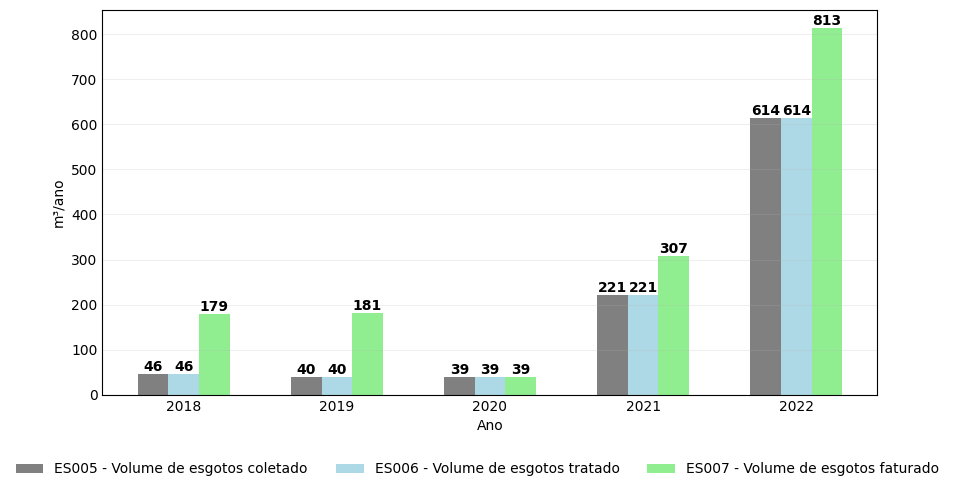

In [15]:
import pandas as pd
import os
import re

# 🔹 Definir o município e os indicadores desejados
INDICADORES_SELECIONADOS = [
    "município","es005","es006","es007","es001","es026","in015","in016","es002","es003","es004"]  # <- Altere os indicadores conforme necessário

# Função para processar os arquivos conforme as regras definidas
def process_excel(file_path, municipio, indicadores):
    xls = pd.ExcelFile(file_path)
    all_sheets = {}

    is_info = "Info" in os.path.basename(file_path)

    for sheet_name in xls.sheet_names:
        df = pd.read_excel(xls, sheet_name=sheet_name, header=None)

        # Certifica que há linhas suficientes antes de definir os cabeçalhos
        if len(df) < 12:
            continue

        # Definir os cabeçalhos conforme o tipo do arquivo
        if is_info:
            header_row_1 = df.iloc[7]  
            header_row_2 = df.iloc[11]  
            start_row = 12  
        else:
            header_row_1 = df.iloc[7]  
            header_row_2 = df.iloc[9]  
            start_row = 10  

        # Criar novo cabeçalho
        new_headers = list(header_row_1[:10]) + list(header_row_2[10:])
        df.columns = [str(h).strip().lower() for h in new_headers]  

        # Remover as linhas de cabeçalho originais
        df = df.iloc[start_row:].reset_index(drop=True)

        # Verificar se há a coluna 'município'
        if df.empty or "município" not in df.columns:
            continue  

        # Filtrar pelo município selecionado
        df["município"] = df["município"].astype(str).str.strip().str.lower()
        df = df[df["município"] == municipio.lower()]

        # Manter apenas os indicadores desejados
        available_columns = [col for col in indicadores if col in df.columns]
        df = df[available_columns]

        # Extrair o ano do nome do arquivo
        match = re.search(r'\b(20\d{2})\b', os.path.basename(file_path))
        df["ano"] = match.group(1) if match else "Desconhecido"
        
        if not df.empty:
            all_sheets[sheet_name] = df

    return all_sheets

# 🔹 Processar os arquivos
arquivos_excel = [os.path.join(DIRETORIO, f) for f in os.listdir(DIRETORIO) if f.endswith(".xlsx")]

data_info = {}
data_ano = {}

for file in arquivos_excel:
    sheets = process_excel(file, MUNICIPIO_SELECIONADO, INDICADORES_SELECIONADOS)
    target_dict = data_info if "Info" in file else data_ano

    for sheet_name, df in sheets.items():
        if sheet_name not in target_dict:
            target_dict[sheet_name] = df  
        else:
            common_cols = target_dict[sheet_name].columns.intersection(df.columns)
            df = df[common_cols]  
            target_dict[sheet_name] = pd.concat([target_dict[sheet_name][common_cols], df], ignore_index=True)

# 🔹 Concatenar os dados separadamente
df_info_concat = pd.concat(data_info.values(), ignore_index=True) if data_info else pd.DataFrame()
df_ano_concat = pd.concat(data_ano.values(), ignore_index=True) if data_ano else pd.DataFrame()

# 🔹 Padronizar colunas antes do merge
for df in [df_info_concat, df_ano_concat]:
    if not df.empty:
        df["ano"] = df["ano"].astype(str).str.strip()
        df["município"] = df["município"].astype(str).str.strip().str.lower()

# 🔹 Realizar o merge
df_final = pd.merge(df_info_concat, df_ano_concat, on=["município", "ano"], how="outer")

# 🔹 Remover linhas vazias
df_final = df_final.dropna(how="all", subset=INDICADORES_SELECIONADOS)

# 🔹 Exportar os dados para Excel
if not df_final.empty:
    output_path = os.path.join(DIRETORIO, "Resultado", f"{MUNICIPIO_SELECIONADO}_Dados-Esgoto-Tabela.xlsx")
    df_final.to_excel(output_path, index=False)
    display(df_final)
    print(f"📂 Arquivo exportado para: {output_path}")
else:
    print(f"⚠ Nenhum dado encontrado para {MUNICIPIO_SELECIONADO}.")

################
##AQUI ELE FAZ O GRÁFICO!!!
###############

import pandas as pd
import matplotlib.pyplot as plt

# Padronizar nomes das colunas removendo espaços extras
df_final.columns = df_final.columns.str.strip()

# Criar a figura e o eixo principal
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plotar as barras para ES005, ES006 e ES007
bar_width = 0.2
x_vals = df_final["ano"].astype(int)

bars1 = ax1.bar(x_vals - 0.2, df_final["es005"].astype(float), width=bar_width, label="ES005 - Volume de esgotos coletado", color="gray")
bars2 = ax1.bar(x_vals - 0.0, df_final["es006"].astype(float), width=bar_width, label="ES006 - Volume de esgotos tratado", color="lightblue")
bars3 = ax1.bar(x_vals + 0.2, df_final["es007"].astype(float), width=bar_width, label="ES007 - Volume de esgotos faturado", color="lightgreen")

# Adicionar valores acima das barras
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, height, f'{height:,.0f}', 
                 ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

# Configurações do eixo Y principal
ax1.set_ylabel("m³/ano")
ax1.set_xlabel("Ano")
ax1.set_xticks(x_vals)
ax1.set_xticklabels(x_vals, fontsize=10)  # Mantém os anos sem os traços dos ticks
ax1.tick_params(axis="x", length=0)  # Remove os ticks do eixo X
ax1.tick_params(axis="y", length=0)  # Remove os ticks do eixo Y

ax1.grid(axis='y', alpha=0.2)

# Criar uma única legenda combinada e remover a borda da legenda
legend = fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0), ncol=3, fontsize=10)
legend.get_frame().set_linewidth(0)  # Remove a borda da legenda

#plt.title("Indicadores de Água e Perdas")
plt.savefig(DIRETORIO+ "\Resultado"+rf"\{MUNICIPIO_SELECIONADO}_Gráfico-Esgoto.png", dpi=300, bbox_inches="tight")  # Salva antes de mostrar
plt.show()


## Resíduos (incompleto)

In [ ]:
INDICADORES_SELECIONADOS = ["município", "co019", "co020", "co050", "co164", "co165", "cs001", "cs009", "cs010",
                            "cs011", "cs012", "cs013", "cs014", "in014", "in015", "in016", "in021",
                            "in032", "in034", "in035", "in038", "in039", "in040", "co134", "co135",
                            "co136", "in028", "in031"]

INDICADORES_DESC = {
    "co019": "CO019 - Os resíduos sólidos domiciliares e públicos coletados são enviados para outro município?",
    "co020": "CO020 - Município(s) de destino de RDO e RPU exportado",
    "co050": "CO050 - População urbana atendida no município, abrangendo o distrito-sede e localidades",
    "co164": "CO164 - População total atendida no município com coleta regular de pelo menos uma vez por semana",
    "co165": "CO165 - População urbana atendida pelo serviço de coleta domiciliar direta, ou seja, porta a porta",
    "cs001": "CS001 - Existe coleta seletiva formalizada pela prefeitura no município?",
    "cs009": "CS009 - Quantidade total de materiais recicláveis recuperados",
    "cs010": "CS010 - Quantidade de Papel e papelão recicláveis recuperados",
    "cs011": "CS011 - Quantidade de Plásticos recicláveis recuperados",
    "cs012": "CS012 - Quantidade de Metais recicláveis recuperados",
    "cs013": "CS013 - Quantidade de Vidros recicláveis recuperados",
    "cs014": "CS014 - Quantidade de Outros materiais recicláveis recuperados (exceto pneus e eletrônicos)",
    "in014": "IN014 - Taxa de cobertura do serviço de coleta domiciliar direta (porta-a-porta) da população urbana do município.",
    "in015": "IN015 - Taxa de cobertura regular do serviço de coleta de RDO em relação à população total do município",
    "in016": "IN016 - Taxa de cobertura regular do serviço de coleta de RDO em relação à população urbana",
    "in021": "IN021 - Massa coletada (RDO + RPU) per capita em relação à população urbana",
    "in032": "IN032 - Massa recuperada per capita de materiais recicláveis (exceto matéria orgânica e rejeitos) em relação à população urbana",
    "in034": "IN034 - Incidência de papel e papelão no total de material recuperado",
    "in035": "IN035 - Incidência de plásticos no total de material recuperado",
    "in038": "IN038 - Incidência de metais no total de material recuperado",
    "in039": "IN039 - Incidência de vidros no total de material recuperado",
    "in040": "IN040 - Incidência de outros materiais (exceto papel, plástico, metais e vidros) no total de material recuperado",
    "co134": "CO134 - Percentual da população atendida com frequência diária",
    "co135": "CO135 - Percentual da população atendida com frequência de 2 ou 3 vezes por semana",
    "co136": "CO136 - Percentual da população atendida com frequência de 1 vez por semana",
    "in028": "IN028 - Massa de resíduos domiciliares e públicos (RDO+RPU) coletada per capita em relação à população total atendida pelo serviço de coleta",
    "in031": "IN031 - Taxa de recuperação de materiais recicláveis (exceto matéria orgânica e rejeitos) em relação à quantidade total (RDO + RPU) coletada",
}
